# [프로젝트] 상수관로 누수 감지 분류 머신러닝

---

## 프로젝트 개요

수도 시설의 이상은 일상에 큰 불편을 초래할 수 있어 조기 감지가 중요한데요.

>"우리 주변의 상수관로 누수 여부를 자동으로 판단하는 서비스를 만들 수 있을까?"     

이번 프로젝트에서는 상수관로 누수 감지 데이터를 바탕으로 누수 유형 분류 머신러닝을 실습합니다.

---

## 프로젝트 목표

- 상수관로 누수 감지 데이터를 바탕으로 누수 유형 분류 모델 학습
- 분류 머신러닝을 위한 탐색적 데이터 분석, 데이터 전처리, 모델 선택 및 최적화 기법 등 머신러닝 기초 학습

---

## 데이터 출처

AI Hub - 상수관로 누수 감지 데이터     
https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=&topMenu=&aihubDataSe=data&dataSetSn=138

---

## 목차
1. 데이터 불러오기
2. 탐색적 데이터 분석 (EDA)
3. 데이터 전처리
4. 상수관로 누수 분류 모델
5. 하이퍼파라미터 최적화

---

## 1. 데이터 불러오기

이번 프로젝트에 필요한 라이브러리를 불러옵니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='NanumGothic')

분석에 사용할 데이터는 상수관로 누수 감지 데이터입니다.
데이터는 다음과 같이 누수 유형별로 구분되어 있습니다.
- 옥외누수 (out)
- 옥내누수 (in)
- 기계/전기음 (noise)
- 환경음 (other)
- 정상음 (normal)

우선 모든 데이터를 불러와 하나의 데이터프레임으로 합쳐줍니다.

In [2]:
# 누수 데이터 불러오기
out_leak_train = pd.read_csv('data/out-training.csv')
in_leak_train = pd.read_csv('data/in-training.csv')
noise_train = pd.read_csv('data/noise-training.csv')
other_train = pd.read_csv('data/other-training.csv')
normal_train = pd.read_csv('data/normal-training.csv')

out_leak_test = pd.read_csv('data/out-validation.csv')
in_leak_test = pd.read_csv('data/in-validation.csv')
noise_test = pd.read_csv('data/noise-validation.csv')
other_test = pd.read_csv('data/other-validation.csv')
normal_test = pd.read_csv('data/normal-validation.csv')

In [3]:
# Concat
train_df = pd.concat([
    out_leak_train,
    in_leak_train,
    noise_train,
    other_train,
    normal_train
], ignore_index=True)

test_df = pd.concat([
    out_leak_test,
    in_leak_test,
    noise_test,
    other_test,
    normal_test
], ignore_index=True)

In [4]:
# 학습 데이터셋 확인
train_df.head()

,site,sid,ldate,lrate,llevel,leaktype,0HZ,10HZ,20HZ,30HZ,...,MAX10,MAX11,MAX12,MAX13,MAX14,MAX15,MAX16,MAX17,MAX18,MAX19
0,S-4687025030,S-0359369085120315,20200708,90,256,out,0,18,19,16,...,4690,243,4710,284,4700,324,4670,230,4710,260
1,S-4677025028,S-0359369083968368,20190601,90,542,out,0,4,2,4,...,310,423,300,711,270,412,270,531,290,538
2,S-4673025027,S-0359369085133797,20201028,90,705,out,0,0,0,3,...,240,751,240,897,240,741,240,741,240,562
3,S-4772025022,S-0359369084117593,20200505,90,499,out,0,2,2,2,...,370,549,360,427,370,800,370,552,370,458
4,S-4729010102,S-0359369084010178,20200520,90,423,out,0,3,3,3,...,400,521,400,395,400,461,400,470,400,515


이번 프로젝트에서는 **상수관로 누수 감지 센서 데이터를 바탕으로 '누수 유형 분류' 머신러닝**을 수행할 예정입니다.   
위 데이터에서 분류 모델의 독립/종속변수로 사용할 컬럼은 다음과 같습니다.

> 독립변수:
> - 누수 감지 주파수 범위 (0 ~ 5120 HZ)
> - 누수 감지 횟수별 감지 정보 (누수감지 n회에서의 최대 주파수 및 최대 누수 크기)
>
> 종속변수:
> - 누수 유형 (`out` / `in` / `noise` / `other` / `normal`)

먼저 독립변수로 사용할 데이터들을 확인해 볼까요?    
누수 감지 주파수 범위를 나타내는 컬럼들은 총 512개가 있고, 컬럼명이 `HZ`로 끝납니다.    
각 주파수별로 감지된 누수 진동 크기가 저장되어 있습니다.

In [5]:
# 누수 감지 주파수 범위 컬럼
hz_columns = hz_columns = [col for col in train_df.columns if col.endswith('HZ')]
train_df[hz_columns].head()

,0HZ,10HZ,20HZ,30HZ,40HZ,50HZ,60HZ,70HZ,80HZ,90HZ,...,5030HZ,5040HZ,5050HZ,5060HZ,5070HZ,5080HZ,5090HZ,5100HZ,5110HZ,5120HZ
0,0,18,19,16,20,19,17,16,20,16,...,23,24,19,16,21,18,17,18,22,20
1,0,4,2,4,6,4,6,8,8,10,...,2,2,2,2,2,2,2,4,2,2
2,0,0,0,3,3,3,3,5,14,14,...,3,3,3,3,3,3,3,3,3,3
3,0,2,2,2,2,2,2,2,2,2,...,2,4,2,4,4,4,4,4,4,4
4,0,3,3,3,3,3,3,3,5,6,...,5,5,5,5,5,5,5,5,5,5


누수 감지 횟수별 감지 정보를 나타내는 컬럼들은 총 20개가 있고, 컬럼명이 `MAX`로 시작합니다.     
다음과 같이 연속된 컬럼들끼리 묶어서 누수 감지 n회로 해석하며, 짝수 번째 컬럼은 '최대 주파수'를, 홀수 번째 컬럼은 '최대 누수 크기'를 나타냅니다.

- `MAX0` / `MAX1`: 누수 감지 1회 최대 주파수 / 최대 누수 크기
- `MAX2` / `MAX3`: 누수 감지 2회 최대 주파수 / 최대 누수 크기
- ...
- `MAX18` / `MAX19`: 누수 감지 10회 최대 주파수 / 최대 누수 크기


In [6]:
# 누수 감지 횟수별 감지 정보
max_columns = [col for col in train_df.columns if col.startswith('MAX')]
train_df[max_columns]

,MAX0,MAX1,MAX2,MAX3,MAX4,MAX5,MAX6,MAX7,MAX8,MAX9,MAX10,MAX11,MAX12,MAX13,MAX14,MAX15,MAX16,MAX17,MAX18,MAX19
0,4680,290,4730,287,4680,205,4730,233,4720,228,4690,243,4710,284,4700,324,4670,230,4710,260
1,300,592,300,486,300,498,300,627,300,647,310,423,300,711,270,412,270,531,290,538
2,240,590,240,835,240,653,230,594,240,735,240,751,240,897,240,741,240,741,240,562
3,370,567,370,348,370,339,370,503,370,593,370,549,360,427,370,800,370,552,370,458
4,400,460,400,427,430,336,430,321,420,282,400,521,400,395,400,461,400,470,400,515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62559,260,248,260,52,190,33,190,31,260,164,190,44,260,60,190,32,260,439,260,77
62560,260,157,180,151,260,87,260,60,180,171,260,196,260,65,260,52,260,38,260,58
62561,310,146,290,185,310,124,310,108,300,137,310,147,290,162,290,226,290,171,310,98
62562,390,143,400,58,390,120,400,42,390,203,390,58,380,94,380,61,380,133,380,67


다음으로 종속변수로 사용할 컬럼인 `leaktype`을 살펴보겠습니다.    
`normal`(정상음), `out`(옥외누수), `in`(옥내누수), `other`(환경음), `noise`(기계/전기음) 총 5개의 클래스로 구분되어 있습니다.

In [7]:
train_df[['leaktype']].value_counts()

leaktype
normal      19704
out         17539
in          13273
other        7019
noise        5029
Name: count, dtype: int64

이렇게 이번 프로젝트에서 사용할 데이터들을 모두 불러왔습니다.     
다음 챕터에서는 탐색적 데이터 분석을 수행하며 데이터를 이해하고 어떻게 전처리할지 고민해 보도록 하겠습니다. 

---

## 2. 탐색적 데이터 분석 (EDA)

이번 챕터에서는 독립변수와 종속변수로 사용할 정보들의 분포를 살펴보겠습니다.

### 2.1. 누수 감지 주파수 범위

먼저, 각 주파수별로 누수 감지 진동의 분포를 살펴봅시다.    
여기서는 종속변수인 `leaktype`별로 그룹화하여 각 주파수의 평균을 구해보도록 하겠습니다.

In [8]:
# 누수 유형별로 그룹화하여 각 주파수별 평균 계산
hz_columns = hz_columns = [col for col in train_df.columns if col.endswith('HZ')]
mean_by_leaktype = train_df.groupby('leaktype')[hz_columns].mean()
mean_by_leaktype

,0HZ,10HZ,20HZ,30HZ,40HZ,50HZ,60HZ,70HZ,80HZ,90HZ,...,5030HZ,5040HZ,5050HZ,5060HZ,5070HZ,5080HZ,5090HZ,5100HZ,5110HZ,5120HZ
leaktype,,,,,,,,,,,,,,,,,,,,,
in,0.0,6.568673,6.802305,7.237475,8.085889,9.004294,14.364951,8.766971,9.290439,10.063512,...,8.828449,8.803436,8.796353,8.824079,8.819408,8.785655,8.822120,8.851277,8.830558,8.849167
noise,0.0,4.493140,5.059853,5.666136,6.284152,6.620203,30.509246,7.387950,7.801153,8.679459,...,4.807715,4.778684,4.777491,4.713263,4.701531,4.741102,4.643667,4.607874,4.580831,4.504076
normal,0.0,4.260607,4.435445,4.629720,4.711226,4.827903,5.488124,4.931384,5.197016,5.593534,...,6.398904,6.372564,6.365560,6.371803,6.355867,6.347391,6.339322,6.323944,6.322320,6.318971
other,0.0,5.365579,5.773187,6.271121,6.352329,6.578145,12.923351,7.426556,7.902835,9.367004,...,7.684286,7.626443,7.628437,7.638410,7.643112,7.691552,7.678587,7.630147,7.631856,7.681579
out,0.0,5.733109,6.025372,6.388563,6.859969,7.373796,8.555505,8.056104,8.771424,10.243115,...,6.962484,6.923257,6.886196,6.817435,6.779235,6.755459,6.726153,6.728377,6.692400,6.676207


위와 같이 누수 유형별로 각 주파수에서의 평균 진동이 계산되었습니다.    
시각화를 통해 각 누수 유형마다 특정 주파수에서의 진동이 높거나 낮은지, 어떤 패턴이 있는지 살펴볼까요?

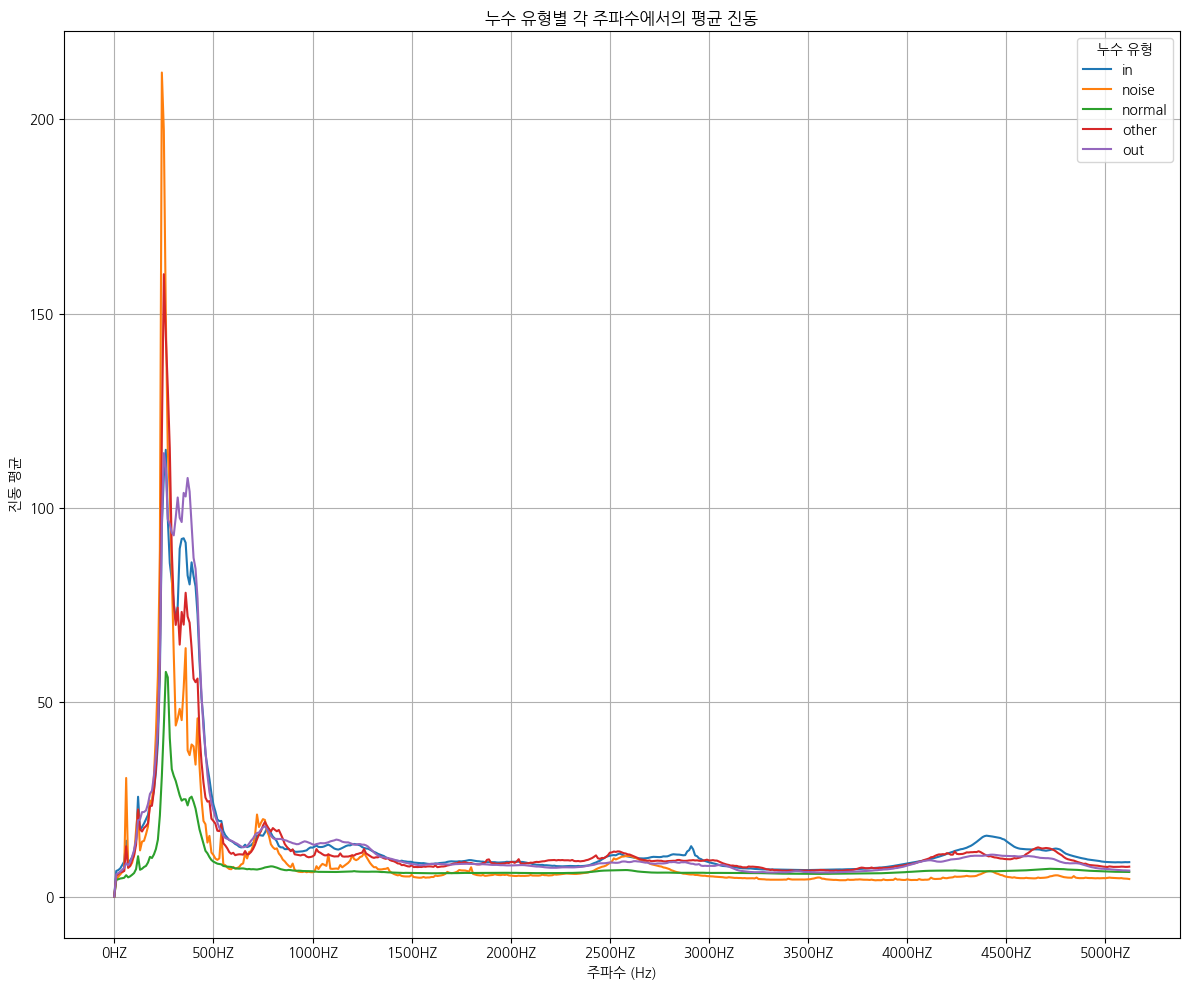

In [9]:
# 시각화
plt.figure(figsize=(12, 10))
for leaktype in mean_by_leaktype.index:
    plt.plot(hz_columns, mean_by_leaktype.loc[leaktype], label=leaktype)

plt.xticks(ticks=range(0, 512, 50))
plt.xlabel("주파수 (Hz)")
plt.ylabel("진동 평균")
plt.title("누수 유형별 각 주파수에서의 평균 진동")
plt.legend(title="누수 유형")
plt.grid(True)
plt.tight_layout()
plt.show()

위 그래프를 살펴보면, 모든 누수 유형에서 0 ~ 500 HZ 사이의 평균이 가장 높은 것을 볼 수 있습니다.    
한편 각 누수 유형별로 특정 주파수에서의 평균값이 크게 구분되는 것을 볼 수 있는데요.   
예를 들어 400 HZ 전후를 보면 `out`, `in`, `other`, `noise`, `normal` 순서대로 평균값이 확실히 구분되는 것을 확인할 수 있습니다.     
주파수 범위라는 독립변수는 누수 유형 구분에 중요한 역할을 하는 변수라고 볼 수 있겠네요.

---

### 2.2. 누수 감지 횟수별 감지 정보

이번엔 누수 감지 횟수별 감지 정보를 분석해 보겠습니다.     
`MAX`로 시작하는 컬럼들은 연속된 컬럼들끼리 묶어서 누수 감지 n회로 해석하며, 짝수 번째 컬럼은 '최대 주파수'를, 홀수 번째 컬럼은 '최대 누수 크기'를 나타냅니다.

- `MAX0` / `MAX1`: 누수 감지 1회 최대 주파수 / 최대 누수 크기
- `MAX2` / `MAX3`: 누수 감지 2회 최대 주파수 / 최대 누수 크기
- ...
- `MAX18` / `MAX19`: 누수 감지 10회 최대 주파수 / 최대 누수 크기

시각화를 위해 '최대 주파수'와 '최대 누수 크기' 컬럼을 'n회' 별로 구분해 볼까요?    
다음과 같이 딕셔너리 형태로 어떤 컬럼이 n회에 속하는지 직관적으로 매핑해 봅시다.

`max_freq_cols`: 최대 주파수 (key: n회, value: 컬럼명)     
`max_leak_cols`: 최대 누수 크기 (key: n회, value: 컬럼명)

```python
max_freq_cols = {
    1: 'MAX0',
    2: 'MAX2',
    ...
}

max_leak_cols = {
    1: 'MAX1',
    2: 'MAX3',
    ...
}
```

In [10]:
# 최대 주파수와 누수 크기 컬럼을 횟수별로 분리
max_columns = [col for col in train_df.columns if col.startswith('MAX')]
max_freq_cols = {}  
max_leak_cols = {}  

for col in max_columns:
    if col == 'MAX':
        idx = 0
    else:
        idx = int(col.replace('MAX', ''))

    round_num = (idx // 2) + 1  # 0,1 → 1회 / 2,3 → 2회 ...

    if idx % 2 == 0 or col == 'MAX':  # 짝수 인덱스 또는 'MAX' → 최대 주파수
        max_freq_cols[round_num] = col
    else:  # 홀수 인덱스 → 최대 누수 크기
        max_leak_cols[round_num] = col

In [11]:
# 최대 주파수
max_freq_cols

{1: 'MAX0',
 2: 'MAX2',
 3: 'MAX4',
 4: 'MAX6',
 5: 'MAX8',
 6: 'MAX10',
 7: 'MAX12',
 8: 'MAX14',
 9: 'MAX16',
 10: 'MAX18'}

In [12]:
# 최대 누수 크기
max_leak_cols

{1: 'MAX1',
 2: 'MAX3',
 3: 'MAX5',
 4: 'MAX7',
 5: 'MAX9',
 6: 'MAX11',
 7: 'MAX13',
 8: 'MAX15',
 9: 'MAX17',
 10: 'MAX19'}

이제 위 딕셔너리를 활용하면 '최대 주파수' 관련 컬럼과 '최대 누수 크기' 관련 컬럼을 손쉽게 구분할 수 있습니다.    
먼저 '최대 주파수' 컬럼들을 `leaktype` 기준으로 그룹화하여 평균을 구해볼까요?

In [13]:
# 누수 유형별로 그룹화하여 각 횟수별 최대 주파수의 평균 계산
mean_freq_by_leaktype = train_df.groupby('leaktype')[[max_freq_cols[i] for i in list(range(1, 11))]].mean()
mean_freq_by_leaktype

,MAX0,MAX2,MAX4,MAX6,MAX8,MAX10,MAX12,MAX14,MAX16,MAX18
leaktype,,,,,,,,,,
in,585.270851,583.426505,584.879078,579.419875,585.016952,585.713102,580.895050,578.635576,578.909817,579.986439
noise,356.577848,355.323126,359.709684,357.458739,355.517996,359.250348,359.604295,357.251939,356.261682,355.836150
normal,436.123630,432.191433,419.919306,428.064860,425.092367,435.786135,429.304710,430.853126,451.469245,440.139566
other,563.774042,563.796837,565.371135,549.868927,559.193617,555.208719,551.525858,562.070095,561.752386,561.957544
out,562.185986,566.744398,562.556588,562.581675,566.797423,564.972917,558.925822,559.081476,559.534751,564.791607


위 데이터를 그래프로 표현해 봅시다. x축은 누수 감지 n회, y축은 최대 주파수의 평균입니다.

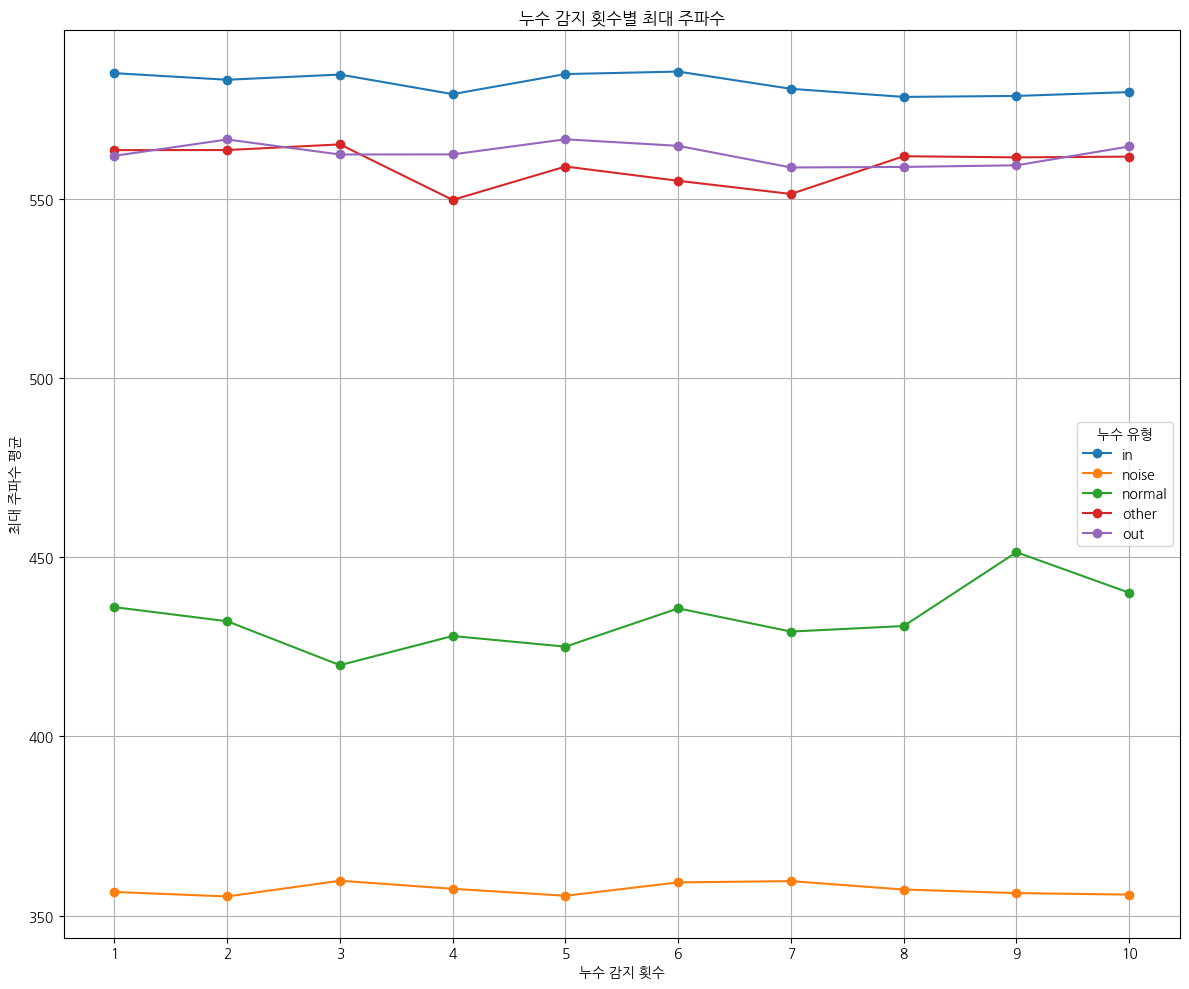

In [14]:
# 시각화
mean_freq_by_leaktype = train_df.groupby('leaktype')[[max_freq_cols[i] for i in list(range(1, 11))]].mean()

plt.figure(figsize=(12, 10))
for leaktype in mean_freq_by_leaktype.index:
    plt.plot(list(range(1, 11)), mean_freq_by_leaktype.loc[leaktype], marker='o', label=leaktype)

plt.title("누수 감지 횟수별 최대 주파수")
plt.xlabel("누수 감지 횟수")
plt.ylabel("최대 주파수 평균")
plt.xticks(ticks=list(range(1, 11)))
plt.grid(True)
plt.legend(title="누수 유형")
plt.tight_layout()
plt.show()

최대 주파수도 각 누수 유형에 따라 확실하게 구분되는 것을 볼 수 있습니다.    
이어서 최대 누수 크기도 시각화해 볼까요?

In [15]:
# 누수 유형별로 그룹화하여 각 횟수별 최대 누수 크기의 평균 계산
mean_leak_by_leaktype = train_df.groupby('leaktype')[[max_leak_cols[i] for i in list(range(1, 11))]].mean()
mean_leak_by_leaktype

,MAX1,MAX3,MAX5,MAX7,MAX9,MAX11,MAX13,MAX15,MAX17,MAX19
leaktype,,,,,,,,,,
in,506.927371,505.527914,505.960973,507.476155,508.523695,506.516914,506.372184,506.775936,506.735101,506.699917
noise,582.123086,582.782263,580.682641,587.858819,588.671306,585.991251,588.920660,586.415788,590.082919,583.675482
normal,169.282582,172.478431,169.310800,167.670879,169.304456,163.645808,162.782075,161.017763,163.186206,160.328969
other,520.653369,523.786009,521.526571,525.374697,525.051147,527.243624,521.950420,525.401767,527.390511,522.479128
out,530.465363,531.621130,530.551286,531.147899,529.106620,528.364331,529.586864,529.224528,528.803638,526.192200


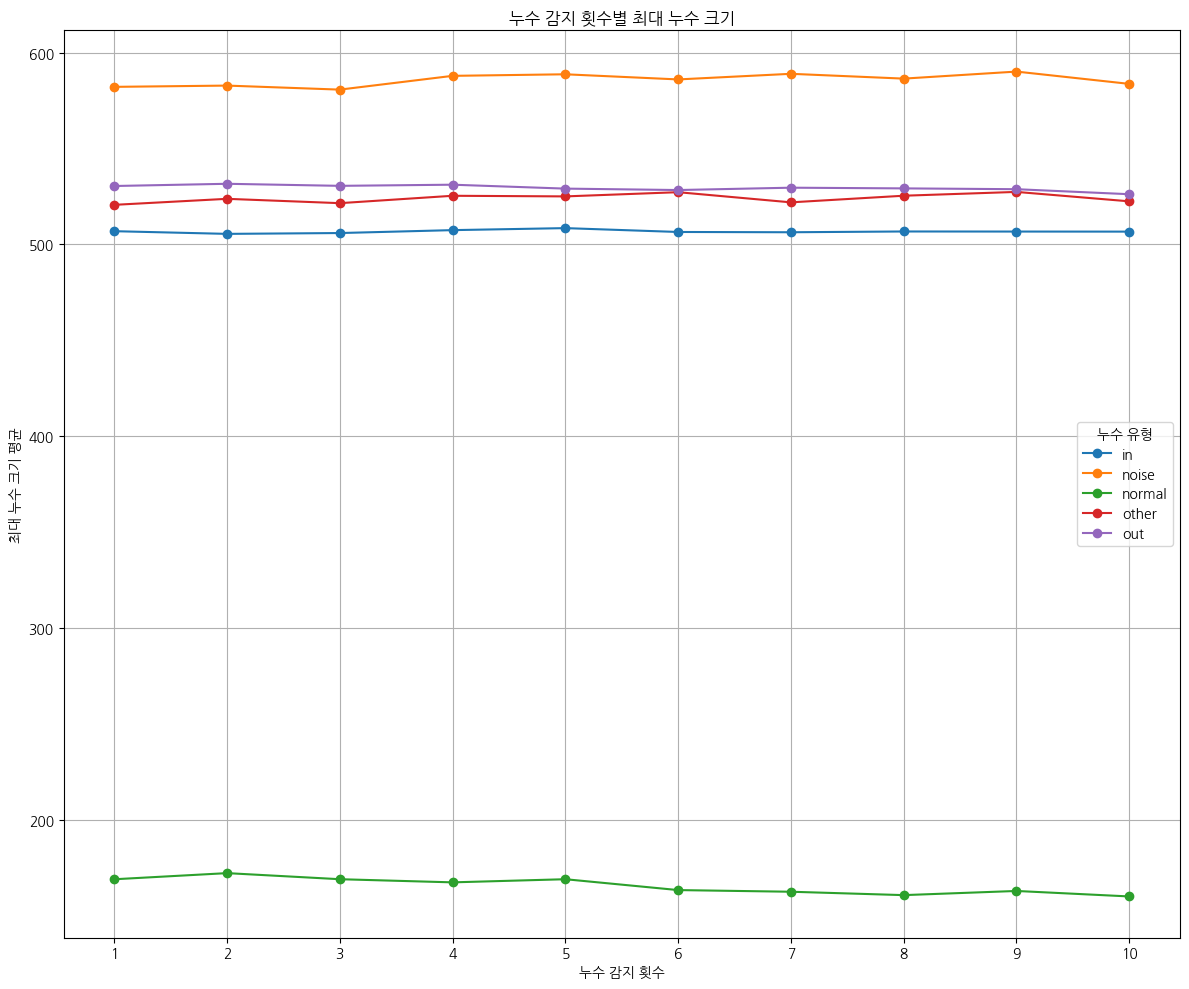

In [16]:
# 시각화
mean_leak_by_leaktype = train_df.groupby('leaktype')[[max_leak_cols[i] for i in list(range(1, 11))]].mean()

plt.figure(figsize=(12, 10))
for leaktype in mean_leak_by_leaktype.index:
    plt.plot(list(range(1, 11)), mean_leak_by_leaktype.loc[leaktype], marker='o', label=leaktype)

plt.title("누수 감지 횟수별 최대 누수 크기")
plt.xlabel("누수 감지 횟수")
plt.ylabel("최대 누수 크기 평균")
plt.xticks(ticks=list(range(1, 11)))
plt.grid(True)
plt.legend(title="누수 유형")
plt.tight_layout()
plt.show()

앞서 최대 주파수와는 조금 다르게, 최대 누수 크기의 경우 `normal`의 값들이 매우 낮은 반면 `noise`의 값들은 높아진 것을 볼 수 있습니다.

---

## 3. 데이터 전처리

이번 챕터에서는 머신러닝 목적에 적합한 형태로 데이터를 전처리하는 실습을 진행하겠습니다.    
전처리 계획은 다음과 같습니다.     

> 독립변수
> - 결측치 제거
> - 스케일링
>
> 종속변수
> - 라벨 인코딩

### 3.1. 누수 감지 센서 데이터 전처리

독립변수인 누수 감지 센서 데이터에 대해서 전처리를 진행해 볼까요?     
먼저 학습/테스트셋에서 독립변수 컬럼만 추출합니다.

In [17]:
# 독립변수
X_train = train_df.drop(columns=['site', 'sid', 'ldate', 'lrate', 'llevel', 'leaktype'])
X_test = test_df.drop(columns=['site', 'sid', 'ldate', 'lrate', 'llevel', 'leaktype'])

학습 데이터에 결측치가 있는지 확인해 봅시다.

In [18]:
print(f"총 결측값 개수: {X_train.isnull().sum().sum()}")

총 결측값 개수: 0


학습 데이터에는 결측치가 존재하지 않네요.    
그럼 이어서 독립변수들의 값을 정규화해 봅시다.

>📌 `MinMaxScaler`는 입력 데이터를 0과 1 사이의 범위로 정규화하여, 모든 특성이 동일한 스케일을 갖도록 합니다. 이를 통해 모델이 변수의 크기에 영향을 받지 않고 균형 있게 학습할 수 있도록 돕습니다.

In [19]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# 정규화 결과 확인
X_train

array([[0.        , 0.21686747, 0.13013699, ..., 0.1293911 , 0.9416499 ,
        0.14756026],
       [0.        , 0.04819277, 0.01369863, ..., 0.30562061, 0.05231388,
        0.31099353],
       [0.        , 0.        , 0.        , ..., 0.42857143, 0.04225352,
        0.32510288],
       ...,
       [0.        , 0.04819277, 0.02739726, ..., 0.09484778, 0.05633803,
        0.05232216],
       [0.        , 0.04819277, 0.03424658, ..., 0.07259953, 0.07042254,
        0.03409759],
       [0.        , 0.04819277, 0.02739726, ..., 0.00468384, 0.05633803,
        0.01352146]], shape=(62564, 533))

---

### 3.2. 누수 유형 전처리

이번에는 종속변수인 누수 유형를 전처리해 보겠습니다.     
먼저 학습/테스트셋에서 종속변수 컬럼만 추출합니다.

In [21]:
# 종속변수
y_train = train_df['leaktype']
y_test = test_df['leaktype']

이제 범주형 데이터를 숫자 라벨로 변환해 줍니다.

> 📌 `LabelEncoder`는 범주형 문자열 데이터를 숫자형 라벨로 변환하여, 머신러닝 모델이 범주형 값을 처리할 수 있도록 합니다. 예를 들어, 클래스 레이블인 'in', 'noise', 'normal'을 각각 0, 1, 2와 같은 정수로 인코딩합니다.

In [22]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [23]:
# 클래스 확인
le.classes_

array(['in', 'noise', 'normal', 'other', 'out'], dtype=object)

`LabelEncoder`가 학습한 고유 클래스들을 오름차순으로 나열해보면 다음과 같습니다.
- `in` → `0`
- `noise` → `1`
- `normal` `2`
- `other` `3`
- `out` `4`


In [24]:
# 인코딩 결과 확인
y_train

array([4, 4, 4, ..., 2, 2, 2], shape=(62564,))

이렇게 독립변수와 종속변수 컬럼에 대해 전처리가 모두 완료되었습니다.    
다음 챕터에서는 이 데이터를 활용하여 분류 모델을 학습해 보겠습니다.

---

## 4. 누수 유형 분류 모델

이번 챕터에서는 누수 감지 센서 데이터를 바탕으로 누수 유형을 분류하는 모델을 실습해 보겠습니다.

### 4.1 DecisionTreeClassifier

먼저, 기본적인 의사결정트리로 분류 모델을 만들어 볼까요?

> 📌 `DecisionTreeClassifier`는 데이터를 분할하여 트리 구조를 만드는 지도학습 분류 모델로, 각 노드에서 조건에 따라 데이터를 나누며 최종 리프 노드에서 분류 결과를 도출합니다. 해석이 쉬우며, 비선형 관계도 잘 모델링한다는 장점이 있습니다.

평가 지표는 다음과 같습니다.

> Confusion Matrix (혼동행렬)    
> - 실제 클래스와 예측 클래스의 분포를 행렬로 나타낸 것으로, True Positive, True Negative, False Positive, False Negative의 수를 통해 모델의 예측 성능을 구체적으로 파악할 수 있습니다.
>
> Classification Report
> - `Accuracy`: 전체 예측 중 맞춘 비율을 의미하며, 값이 높을수록 모델의 전반적인 예측 성능이 좋습니다.
>
> - `Precision`: 양성으로 예측한 것 중 실제로 양성인 비율로, 값이 높을수록 거짓 양성(False Positive)이 적음을 의미합니다.
>
> - `Recall`: 실제 양성 중 모델이 양성으로 맞게 예측한 비율로, 값이 높을수록 거짓 음성(False Negative)이 적음을 의미합니다.
>
> - `F1-score`: Precision과 Recall의 조화 평균으로, 두 지표의 균형을 평가하며 값이 높을수록 모델이 안정적으로 잘 예측했음을 의미합니다.
> 
> - `Macro avg`: 클래스별 지표의 단순 평균으로, 각 클래스의 중요도를 동일하게 평가하며 값이 높을수록 전반적인 균형 잡힌 성능을 의미합니다.
> 
> - `Weighted avg`: 클래스별 지표를 각 클래스의 샘플 수로 가중 평균한 값으로, 값이 높을수록 전체 데이터 분포를 고려했을 때 모델 성능이 우수함을 의미합니다.

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 모델 정의 및 학습
dt_clf = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = dt_clf.predict(X_test)

print("Decision Tree Classifier")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

Decision Tree Classifier

Confusion Matrix

[[ 389   64   29    0 1177]
 [  18  127    6    0  478]
 [   9   12 2397    2   42]
 [ 140   70   18    0  650]
 [ 288   37   34    0 1833]]

Classification Report

              precision    recall  f1-score   support

          in       0.46      0.23      0.31      1659
       noise       0.41      0.20      0.27       629
      normal       0.96      0.97      0.97      2462
       other       0.00      0.00      0.00       878
         out       0.44      0.84      0.58      2192

    accuracy                           0.61      7820
   macro avg       0.45      0.45      0.43      7820
weighted avg       0.56      0.61      0.55      7820



분류 결과를 살펴보면 Weighted F1이 0.55로, 분류 성능이 좋지 않습니다.     
의사결정트리 외에 더 고도화된 분류 모델을 사용해 보는 것이 좋겠습니다.     

한편 의사결정트리 모델은 내부 분류 구조를 시각화할 수도 있습니다.

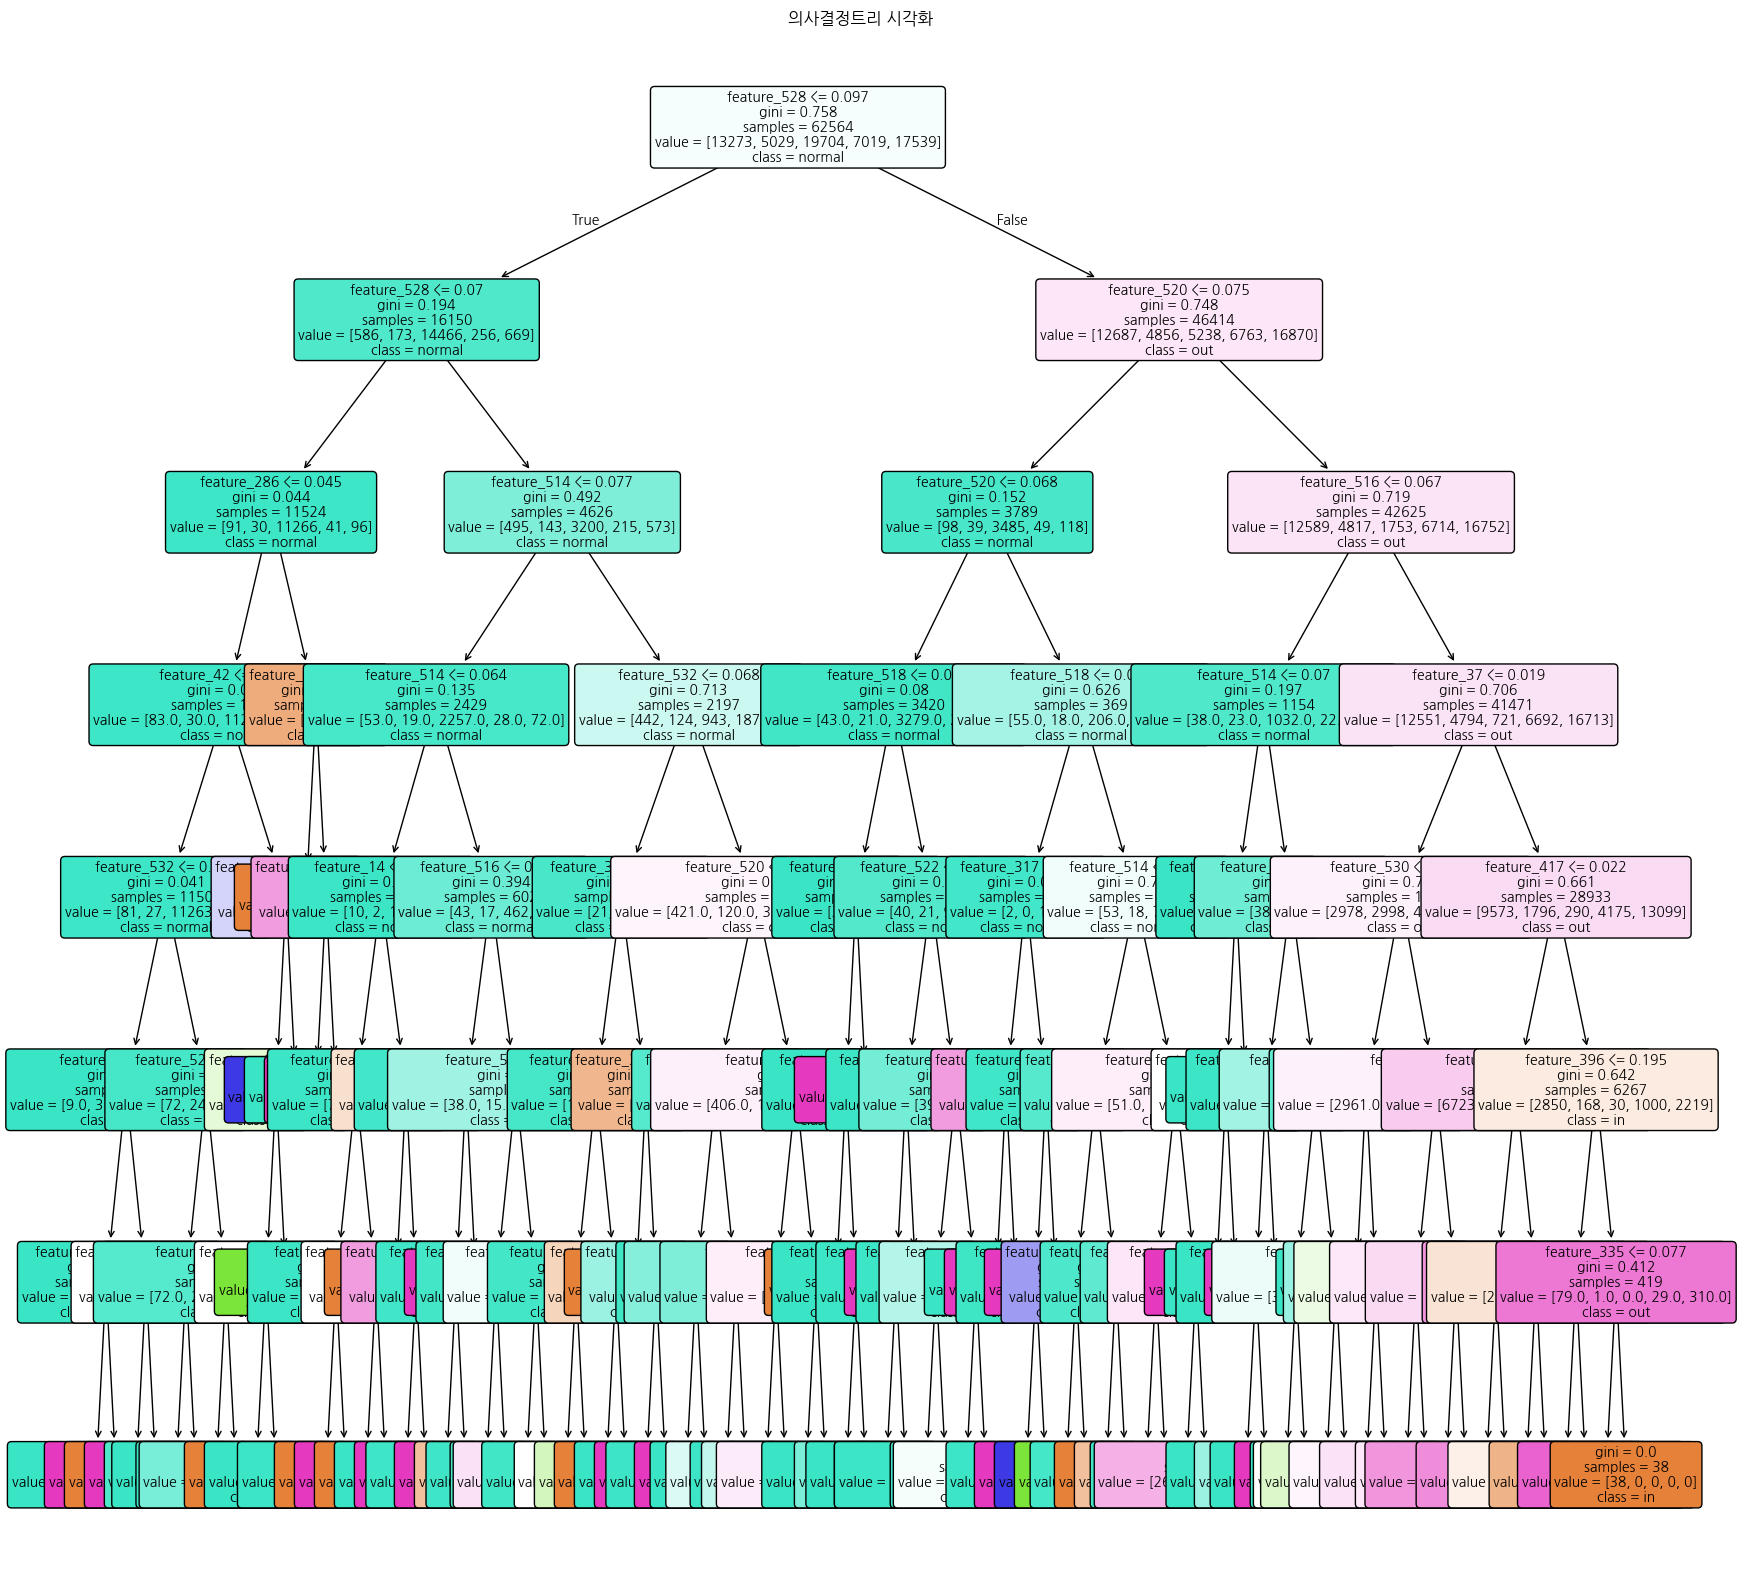

In [26]:
from sklearn.tree import plot_tree

feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
plt.figure(figsize=(20, 20))
plot_tree(dt_clf, 
          #max_depth=3,
          filled=True, 
          feature_names=feature_names,
          class_names=['in', 'noise', 'normal', 'other', 'out'], 
          rounded=True,
          fontsize=10)

plt.title("의사결정트리 시각화")
plt.show()

위의 시각화는 데이터가 각 분기점에서 조건(예: feature_528 <= 0.097)에 따라 나뉘어 최종적으로 어떤 클래스로 분류되는지를 보여주는 흐름도입니다.     
이번 프로젝트의 경우 독립변수의 수가 매우 많기 떄문에 분류도가 매우 복잡해졌다는 점을 참고해 주세요.

---

### 4.2. RandomForestClassifier

앞서 실습한 의사결정트리는 데이터에 민감해 과적합이 발생하기 쉽고, 작은 변화에도 모델 구조가 크게 달라질 수 있는 한계점이 있어 예측 성능이 낮아질 수 있습니다.    
이번엔 `RandomForestClassifier`로 분류 모델을 학습해 봅시다.

> 📌 `RandomForestClassifier`는 여러 개의 의사결정트리를 랜덤하게 만들어 학습하고, 그 예측 결과를 투표 방식으로 결합해 최종 분류를 수행하는 앙상블 학습 모델입니다. 데이터 샘플과 특성을 무작위로 선택해 각 트리를 구성함으로써 편향은 낮추고, 분산을 줄여 과적합을 방지합니다. 높은 예측 성능과 안정성, 그리고 feature importance 분석 기능이 주요 장점입니다.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 모델 정의 및 학습
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = rf_clf.predict(X_test)

print("Random Forest Classifier")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

Random Forest Classifier

Confusion Matrix

[[ 778   42   98    2  739]
 [  66  202   29    3  329]
 [   1    0 2461    0    0]
 [ 130   52   60  150  486]
 [ 154   43   76    2 1917]]

Classification Report

              precision    recall  f1-score   support

          in       0.69      0.47      0.56      1659
       noise       0.60      0.32      0.42       629
      normal       0.90      1.00      0.95      2462
       other       0.96      0.17      0.29       878
         out       0.55      0.87      0.68      2192

    accuracy                           0.70      7820
   macro avg       0.74      0.57      0.58      7820
weighted avg       0.74      0.70      0.67      7820



Weighted F1이 0.67로, 앞서 의사결정트리보다 성능이 크게 개선된 것을 확인할 수 있습니다.     
현재 모델 학습 파라미터는 `n_estimators`=100, `max_depth`=10으로 설정하였는데요.     
최적의 하이퍼파라미터를 찾으면 성능을 지금보다 더 올릴 수 있을 것 같네요!     
GridSearch와 같은 방법이 있지만, 우선은 아래 **TODO**에서 직접 하이퍼파리미터를 조금씩 조정해보며 성능 변화를 체험해 봅시다.     
(자동화된 하이퍼파라미터 튜닝은 다음 챕터에서 실습합니다.)

### <span style="font-size:24px">[TODO] RandomForestClassifier 학습</span>

- 목표: RandomForestClassifier 모델 학습 및 평가
- 수행 방법: 아래 코드에서 `[TODO]`로 표시된 빈칸들을 작성해세요.
- 채점: 파라미터를 조절하며 모델을 학습 및 평가하고, weighted f1-score가 일정 수치 이상인 경우 통과
    - weighted avg: 0.65 이상인 경우 통과

In [28]:
# 모델 정의 및 학습
rf_clf = RandomForestClassifier(
    #################################### 
    # [TODO] 모델 학습 파라미터를 작성하세요.
    # 힌트: 여러 파라미터를 실험해보며 최적의 파라미터를 찾아보세요.
    #      성능 개선이 어려운 경우 위 코드의 파라미터와 아주 유사하게 작성해도 괜찮습니다.
    #      예를 들어 n_estimators는 100으로 고정하고 max_depth를 조금만 높여보세요.
    n_estimators=100,
    max_depth=12,
    random_state=42
    ###################################   
)

#################################### 
# [TODO] 모델 학습 코드를 작성하세요.
# 힌트: 독립변수는 X_train, 종속변수는 y_train입니다. 
rf_clf.fit(X_train, y_train)
####################################


#################################### 
# [TODO] 모델 평가 코드를 작성하세요.
# 힌트: 아래 None으로 선언된 임시 변수들을 활용하여 테스트 셋에 대한 모델 예측 값과 평가 결과를 저장하세요. 
#      classification_report에서 output_dict=True를 통해 딕셔너리 형태로 저장해야 채점이 가능합니다.
#      *해당 변수들은 채점 기준이 되는 변수들이므로 변수명을 절대 변경하지 마세요!*
y_pred = rf_clf.predict(X_test)
classification_report_todo1 = classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out'], output_dict=True)
####################################

print("Random Forest Classifier")
print()
print(f"Weighted F1: {classification_report_todo1['weighted avg']['f1-score']}")

Random Forest Classifier

Weighted F1: 0.740036881907258


---

### 4.3. XGBClassifier

이번엔 `XGBClassifier`로 분류 모델을 학습해 봅시다.   

> 📌 `XGBClassifier`는 Gradient Boosting 기반의 고성능 분류 모델로, 여러 약한 학습기를 순차적으로 학습시키며 이전 모델의 오류를 보완해 예측 성능을 점점 향상시키는 방식입니다. 정확도와 속도 면에서 매우 우수하며, 대규모 데이터나 실무 환경에서도 널리 사용됩니다.     
> 여러 결정트리를 무작위로 학습시켜 그 결과를 평균 또는 다수결로 결정하는 Bagging 방식의 `RandomForestClassifier`와 달리, `XGBClassifier`는 Boosting 방식으로 각 모델이 순차적으로 학습되고, 이전 모델의 오류를 반영하여 다음 모델을 개선하는 구조를 가집니다.

In [29]:
from xgboost import XGBClassifier

# 모델 정의 및 학습
xgb_clf = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)
xgb_clf.fit(X_train, y_train)

# 예측 및 평가
y_pred = xgb_clf.predict(X_test)

print("XGBoost Classifier")
print()
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

XGBoost Classifier

Confusion Matrix

[[1069   56    9   20  505]
 [  74  409    0   11  135]
 [   0    0 2462    0    0]
 [ 140   46    3  375  314]
 [ 157   30    7   18 1980]]

Classification Report

              precision    recall  f1-score   support

          in       0.74      0.64      0.69      1659
       noise       0.76      0.65      0.70       629
      normal       0.99      1.00      1.00      2462
       other       0.88      0.43      0.58       878
         out       0.67      0.90      0.77      2192

    accuracy                           0.80      7820
   macro avg       0.81      0.72      0.75      7820
weighted avg       0.82      0.80      0.80      7820



`XGBClassifier` 모델의 성능을 살펴보면 Weighted F1이 0.80으로, 앞서 `RandomForestClassifier`보다 개선되었음을 확인할 수 있습니다.

---

## 5. 하이퍼파라미터 최적화

앞서 세 가지의 모델의 실습을 통해, 모델의 종류 및 하이퍼파라미터에 따라 성능이 달라지는 것을 확인하셨을 텐데요.    
이번 챕터에서는 하이퍼파라미터들을 최적화하여 높은 성능을 내는 모델을 학습하는 실습을 진행하겠습니다.

### 5.1. L1, L2 정규화

L1, L2 정규화는 모델의 일반화 성능을 향상시키기 위한 기법이며, 정규화 계수인 alpha 또는 lambda 하이퍼파라미터 튜닝의 중요한 대상입니다.

>📌`L1 정규화(Lasso)`는 모델의 가중치 중 일부를 0으로 만들어 변수 선택 효과를 가지며, 희소한 모델을 만드는 데 유리합니다.    
> 반면, `L2 정규화(Ridge)`는 가중치를 0에 가깝게 줄여 전체적으로 매끄럽고 안정적인 모델을 만드는 데 효과적입니다.     
> 두 기법 모두 과적합을 방지하고 일반화 성능을 높이기 위한 정규화 방식으로, alpha 또는 lambda 값에 따라 모델 성능에 큰 영향을 미칩니다.

먼저 L1, L2 정규화 계수를 모두 0으로 하여 정규화를 진행하지 않는 경우의 모델 성능을 살펴볼까요?

In [30]:
xgb_clf = XGBClassifier(
    n_estimators=50,
    learning_rate=0.3,
    max_depth=6,
    random_state=42,
    reg_alpha=0,  # L1
    reg_lambda=0, # L2
    n_jobs=-1,
    verbosity=1
)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print("XGBoost Classifier (alpha:0, lambda:0)")
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

XGBoost Classifier (alpha:0, lambda:0)

Classification Report

              precision    recall  f1-score   support

          in       0.78      0.75      0.76      1659
       noise       0.76      0.69      0.73       629
      normal       1.00      1.00      1.00      2462
       other       0.84      0.59      0.69       878
         out       0.75      0.89      0.81      2192

    accuracy                           0.84      7820
   macro avg       0.83      0.78      0.80      7820
weighted avg       0.85      0.84      0.84      7820



이번엔 L1 정규화 계수인 alpha만 1로 올려보겠습니다.

In [31]:
xgb_clf = XGBClassifier(
    n_estimators=50,
    learning_rate=0.3,
    max_depth=6,
    random_state=42,
    reg_alpha=1,  # L1
    reg_lambda=0, # L2
    n_jobs=-1,
    verbosity=1
)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print("XGBoost Classifier (alpha:1, lambda:0)")
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

XGBoost Classifier (alpha:1, lambda:0)

Classification Report

              precision    recall  f1-score   support

          in       0.78      0.75      0.76      1659
       noise       0.76      0.69      0.72       629
      normal       1.00      1.00      1.00      2462
       other       0.84      0.58      0.69       878
         out       0.75      0.89      0.82      2192

    accuracy                           0.84      7820
   macro avg       0.83      0.78      0.80      7820
weighted avg       0.85      0.84      0.84      7820



정규화 전과 비교하여 큰 변화는 보이지 않습니다.    
다음으로 L2 정규화 계수인 lambda만 1로 올려보겠습니다.

In [32]:
xgb_clf = XGBClassifier(
    n_estimators=50,
    learning_rate=0.3,
    max_depth=6,
    random_state=42,
    reg_alpha=0,  # L1
    reg_lambda=1, # L2
    n_jobs=-1,
    verbosity=1
)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print("XGBoost Classifier (alpha:0, lambda:1)")
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

XGBoost Classifier (alpha:0, lambda:1)

Classification Report

              precision    recall  f1-score   support

          in       0.79      0.75      0.76      1659
       noise       0.75      0.70      0.73       629
      normal       1.00      1.00      1.00      2462
       other       0.85      0.58      0.69       878
         out       0.75      0.89      0.82      2192

    accuracy                           0.84      7820
   macro avg       0.83      0.78      0.80      7820
weighted avg       0.85      0.84      0.84      7820



`noise` 클래스의 F1이 아주 조금 오른 것 외에는 이번에도 Weighted F1의 변화는 없습니다.     
마지막으로, alpha와 lambda 모두 1로 올려보겠습니다.

In [33]:
xgb_clf = XGBClassifier(
    n_estimators=50,
    learning_rate=0.3,
    max_depth=6,
    random_state=42,
    reg_alpha=1,  # L1
    reg_lambda=1, # L2
    n_jobs=-1,
    verbosity=1
)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print("XGBoost Classifier (alpha:1, lambda:1)")
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out']))

XGBoost Classifier (alpha:1, lambda:1)

Classification Report

              precision    recall  f1-score   support

          in       0.78      0.74      0.76      1659
       noise       0.77      0.72      0.74       629
      normal       1.00      1.00      1.00      2462
       other       0.87      0.61      0.72       878
         out       0.76      0.89      0.82      2192

    accuracy                           0.85      7820
   macro avg       0.83      0.79      0.81      7820
weighted avg       0.85      0.85      0.85      7820



이번에는 Weighted F1이 조금 상승했네요!     
이와 같이 정규화 계수를 어떻게 조절하느냐에 따라서 모델 성능이 개선될 수 있다는 점을 확인할 수 있습니다.

---

### 5.2. StratifiedKFold

하이퍼파라미터 최적화에서는 모델이 훈련 데이터에 과적합되지 않도록 하면서, 다양한 설정(max_depth 등)에 대해 일반화 성능이 가장 좋은 조합을 찾는 것이 중요합니다.    
이때 **단일 검증 세트만으로 성능을 판단하면 데이터 분할에 따라 결과가 달라질 수 있어**신뢰도가 낮아집니다. 따라서 `K-Fold 교차검증`을 사용하면 **데이터를 K개의 부분으로 나눠 여러 번 모델을 평가하고 평균 성능을 비교**함으로써, 더 안정적이고 일반화된 성능 기준으로 하이퍼파라미터를 선택할 수 있습니다.

여기서는 `StratifiedKFold`를 간단히 실습해보며 데이터가 실제로 어떻게 나뉘는지 확인해 보도록 하겠습니다. 

>📌 `StratifiedKFold`는 K-폴드 교차검증에서 **각 폴드에 클래스 비율이 원래 데이터와 유사하도록 분할**해주는 방식입니다. 불균형한 클래스 분포에서도 모든 폴드가 대표성을 갖도록 하여, 더 안정적이고 신뢰할 수 있는 하이퍼파라미터 튜닝과 모델 평가가 가능해집니다.

먼저 전체 데이터 중 100개를 무작위로 샘플링 합니다.

In [34]:
from sklearn.model_selection import train_test_split

# 전체 X_train과 y_train에서 100개를 무작위로 샘플링
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=100, stratify=y_train, random_state=42
)

n_samples = X_train_sample.shape[0]
ids = np.array([f"id_{i}" for i in range(n_samples)])
id_to_index = {id_: i for i, id_ in enumerate(ids)}

그리고 샘플 데이터에 대해 `StratifiedKFold`를 적용합니다.     
데이터를 셔플하여 5개의 폴드를 만듭니다.

In [35]:
from sklearn.model_selection import StratifiedKFold

# 5 fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

과연 모든 데이터가 각 폴드마다 적절하게 셔플되었을까요?     
아래 시각화를 통해 각 폴드별 train/val 세트를 확인해 봅시다.   
- 하늘색: 해당 폴드에서 훈련(training) 세트에 포함된 샘플
- 빨간색: 해당 폴드에서 검증(validation) 세트에 포함된 샘플




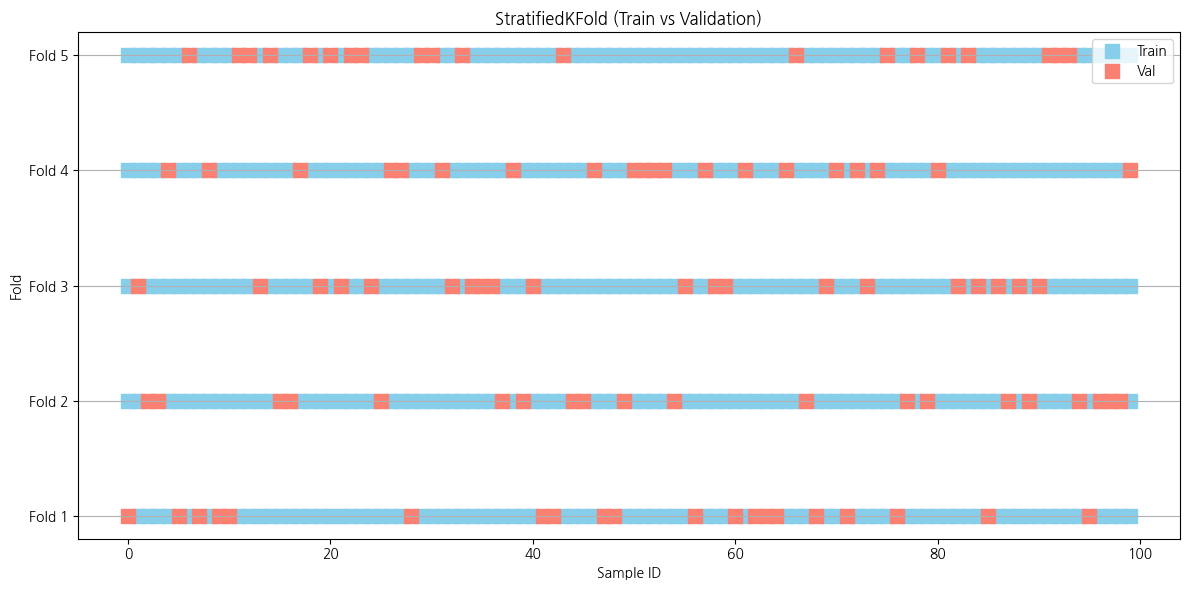

In [36]:
# 시각화
plt.figure(figsize=(12, 6))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sample, y_train_sample), 1):
    train_ids = ids[train_idx]
    val_ids = ids[val_idx]

    # train samples
    plt.scatter(
        [id_to_index[i] for i in train_ids],
        [fold] * len(train_ids),
        color='skyblue',
        label="Train" if fold == 1 else "",
        marker='s',
        s=100
    )

    # validation samples
    plt.scatter(
        [id_to_index[i] for i in val_ids],
        [fold] * len(val_ids),
        color='salmon',
        label="Val" if fold == 1 else "",
        marker='s',
        s=100
    )

plt.yticks(ticks=range(1, 6), labels=[f"Fold {i}" for i in range(1, 6)])
plt.xlabel("Sample ID")
plt.ylabel("Fold")
plt.title("StratifiedKFold (Train vs Validation)")
plt.grid(True, axis='y')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

각 폴드마다 빨간색 검증 샘플이 고르게 퍼져 있는 것을 볼 수 있습니다.     
즉 모든 샘플이 한 번씩은 검증 세트에 포함되고, 나머지에서는 훈련 세트로 사용되었는데요.    
이렇게 각 샘플은 학습과 평가에 모두 사용되며, 모델의 일반화 성능을 평가하기에 유리한 구조가 만들어집니다.

이번에는 원래 클래스 비율을 유지하면서 각 폴드가 나누어졌는지 확인해 볼까요?    
각 폴드별로 클래스별 비율을 누적 막대를 통해 표현해 보겠습니다. 

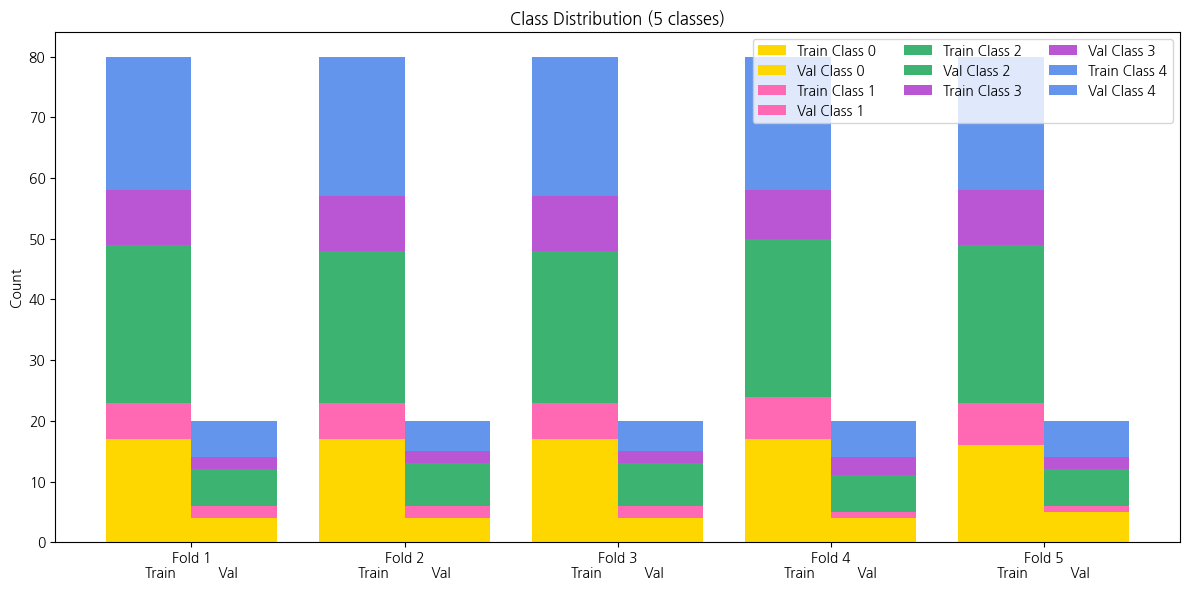

In [37]:
# 클래스 분포 저장용 리스트
n_classes = 5
train_dists = []
val_dists = []

# Fold별 클래스 분포 계산
for _, (train_idx, val_idx) in enumerate(skf.split(X_train_sample, y_train_sample), 1):
    train_counts = np.bincount(y_train_sample[train_idx], minlength=n_classes)
    val_counts = np.bincount(y_train_sample[val_idx], minlength=n_classes)
    train_dists.append(train_counts)
    val_dists.append(val_counts)

train_dists = np.array(train_dists)
val_dists = np.array(val_dists)

x = np.arange(len(train_dists))  # Fold 번호
bar_width = 0.4

plt.figure(figsize=(12, 6))

# 누적 막대 초기값
train_bottom = np.zeros(len(train_dists))
val_bottom = np.zeros(len(val_dists))

colors = ['gold', 'hotpink', 'mediumseagreen', 'mediumorchid', 'cornflowerblue']

for cls in range(n_classes):
    plt.bar(x - bar_width/2, train_dists[:, cls],
            bottom=train_bottom,
            width=bar_width,
            label=f"Train Class {cls}",
            color=colors[cls])
    
    plt.bar(x + bar_width/2, val_dists[:, cls],
            bottom=val_bottom,
            width=bar_width,
            label=f"Val Class {cls}",
            color=colors[cls],
            )

    train_bottom += train_dists[:, cls]
    val_bottom += val_dists[:, cls]

plt.xticks(x, [f"Fold {i+1}\nTrain           Val" for i in x])
plt.ylabel("Count")
plt.title("Class Distribution (5 classes)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

각 폴드의 훈련 및 검증 세트 모두 클래스 비율이 유사합니다.     
즉 `StratifiedKFold`가 각 폴드마다 원래 데이터셋의 클래스 분포를 최대한 유지하도록 데이터를 나눴다는 것을 알 수 있네요.    
앞으로 이를 활용하여 자동화된 하이퍼파라미터 튜닝을 진행해보도록 하겠습니다.

---

### 5.3. Optuna

사용자가 매번 하이퍼파라미터를 조금씩 바꿔가며 모델을 학습하고 결과를 확인하는 과정을 반복하는 것은 비효율적이고 부담이 큽니다.   
그래서 GridSearchCV와 같은 자동화된 하이퍼파라미터 탐색 도구를 사용하면, 다양한 하이퍼파라미터 조합을 체계적으로 실험하고 교차검증을 통해 가장 성능이 좋은 조합을 자동으로 찾아낼 수 있어 시간과 노력을 크게 절약할 수 있습니다.   
여기서는 `Optuna`(https://optuna.org/)를 활용하여 `XGBClassifier` 모델의 하이퍼파라미터를 최적화해 보겠습니다.    

> 📌 `Optuna`는 간편한 하이퍼파라미터 최적화 프레임워크로, 유연한 탐색 공간 정의, 최신 알고리즘을 통한 효율적인 탐색과 조기 중단 등으로 빠르고 효과적인 하이퍼파라미터 최적화를 할 수 있다는 점이 특징입니다.


먼저 다음과 같이 탐색 objective를 적용해 줍니다.    
`params`에서 탐색이 필요한 파라미터를 `trial.suggest_categorical(name, List)` 또는 `trial.suggest_int(name, low, high)`와 같은 식으로 적어줍니다.     
- `suggest_categorical(name, list)`인 경우 'list' 안에 저장된 value들에 대해 탐색이 진행됩니다. 
- `suggest_int(name, low, high)` 및 `suggest_float(name, low, high)`인 경우 'low'와 'high' 사이의 숫자 범위에서 탐색이 이루어집니다.

예를 들어 다른 하이퍼파라미터들은 고정하고, 'learning_rate'만 0.1 또는 0.3 두 가지 옵션 중에서 더 좋은 것을 탐색하고 싶다면, 다음과 같이 설정하면 됩니다.

In [38]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

def objective(trial):
    params = {
        'n_estimators': 50,
        'learning_rate': trial.suggest_categorical('learning_rate', [0.1, 0.3]),  # learnging rate 탐색
        'max_depth': 2,
        'reg_lambda': 1,
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBClassifier(**params)

    # 5 fold 교차 검증으로 f1_weighted 평가
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring=make_scorer(f1_score, average='weighted'))

    return scores.mean()

/home/elicer/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


그리고 Optuna를 실행하여 최적의 파라미터를 자동으로 탐색해 봅시다.

In [39]:
# Optuna 스터디 실행
n_trials = 2 # 경우의 수 (여기서는 0.1 또는 0.3 둘 중 하나를 고르는 경우의 수이므로 2)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=2, show_progress_bar=True)

# 결과 출력
print("Best trial:")
print(f"Score: {study.best_value}")
print("Params:")
for key, value in study.best_params.items():
    print(f"    - {key}: {value}")

[I 2026-07-11 06:52:29,026] A new study created in memory with name: no-name-bc499345-aeb5-41ec-91db-f4cb319ce5d9
Best trial: 0. Best value: 0.565386:  50%|█████     | 1/2 [00:44<00:44, 44.97s/it]

[I 2026-07-11 06:53:13,987] Trial 0 finished with value: 0.5653857600875931 and parameters: {'learning_rate': 0.1}. Best is trial 0 with value: 0.5653857600875931.


Best trial: 1. Best value: 0.653571: 100%|██████████| 2/2 [01:33<00:00, 46.50s/it]

[I 2026-07-11 06:54:02,021] Trial 1 finished with value: 0.6535714455275491 and parameters: {'learning_rate': 0.3}. Best is trial 1 with value: 0.6535714455275491.
Best trial:
Score: 0.6535714455275491
Params:
    - learning_rate: 0.3


결과를 보면, 5 fold CV를 통해 얻은 결과로는 learning_rate가 0.3일 때가 가장 좋았다는 것을 볼 수 있습니다.

자, 이제 마지막으로 위 예시들을 모두 종합하여, Optuna를 활용한 하이퍼파라미터 탐색 및 모델 학습을 전체적으로 실습해 봅시다!

### <span style="font-size:24px">[TODO] Optuna를 활용한 하이퍼파라미터 탐색 및 모델 학습</span>

- 목표: Optuna를 통해 최적의 하이퍼파라미터 탐색 후 해당 하이퍼파라미터로 XGBClassifier 모델 학습
- 수행 방법: 아래 코드에서 `[TODO]`로 표시된 빈칸들을 작성해세요.
- 채점: Optuna를 통해 탐색한 최적의 하이퍼파라미터로 모델을 학습 및 평가하고, 해당 모델의 weighted f1-score가 일정 수치 이상인 경우 통과
    - weighted avg: 0.90 이상인 경우 통과

In [40]:
def objective(trial):
    params = {
        #################################### 
        # [TODO] 하이퍼파라미터 탐색 코드를 작성하세요.
        # 힌트: 'learning_rate'와 'max_depth'에 대해서 하이퍼파라미터 탐색을 수행하세요.
        #      성능 재현 및 평가를 위해 나머지 파라미터들은 변경하거나 새로 탐색하지 마세요.
        #      탐색 범위가 넓을 경우 코드 실행 시간이 굉장히 오래 걸릴 수 있습니다.
        #      추천 범위는 다음과 같습니다.
        #      'learning_rate': [0.1, 0.3] (categorical)
        #      'max_depth': [6, 8] (categorical)
        'learning_rate': trial.suggest_categorical('learning_rate', [0.1, 0.3]),
        'max_depth': trial.suggest_categorical('max_depth', [6, 8]),
        ###################################   
        'n_estimators': 100,
        'reg_lambda': 1,
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBClassifier(**params)


    #################################### 
    # [TODO] 5 fold 교차검증 코드를 작성하세요.
    # 힌트: StratifiedKFold 코드를 참고하세요. 
    #      성능 재현을 위해 shuffle=True, random_state=42로 설정하세요.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    ####################################
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring=make_scorer(f1_score, average='weighted'))

    return scores.mean()


#################################### 
# [TODO] Optuna 스터디 실행 코드를 작성하세요.
# 힌트: 앞선 Optuna 실행 코드를 참고하세요. 
#      n_trials의 경우 탐색에 필요한 경우의 수를 계산하여 적어주세요. 예를 들어 위에서 추천하는 categorical 범위라면 2 x 2 = 4입니다.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=4, show_progress_bar=True)
####################################


print("Best trial:")
print(f"Score: {study.best_value}")
print("Params:")
best_params_todo2 = {}
for key, value in study.best_params.items():
    best_params_todo2[key] = value
    print(f"    - {key}: {value}")

[I 2026-07-11 06:54:02,043] A new study created in memory with name: no-name-ed497bf7-a50f-4e80-9cf9-a9961e035e07
Best trial: 0. Best value: 0.902187:  25%|██▌       | 1/4 [03:48<11:25, 228.35s/it]

[I 2026-07-11 06:57:50,389] Trial 0 finished with value: 0.9021873004646148 and parameters: {'learning_rate': 0.3, 'max_depth': 6}. Best is trial 0 with value: 0.9021873004646148.


Best trial: 1. Best value: 0.933485:  50%|█████     | 2/4 [08:47<08:59, 269.88s/it]

[I 2026-07-11 07:02:49,339] Trial 1 finished with value: 0.9334845938862889 and parameters: {'learning_rate': 0.3, 'max_depth': 8}. Best is trial 1 with value: 0.9334845938862889.


Best trial: 1. Best value: 0.933485:  75%|███████▌  | 3/4 [12:49<04:17, 257.40s/it]

[I 2026-07-11 07:06:51,891] Trial 2 finished with value: 0.9334845938862889 and parameters: {'learning_rate': 0.3, 'max_depth': 8}. Best is trial 1 with value: 0.9334845938862889.


Best trial: 1. Best value: 0.933485: 100%|██████████| 4/4 [15:29<00:00, 232.26s/it]

[I 2026-07-11 07:09:31,098] Trial 3 finished with value: 0.806907701695977 and parameters: {'learning_rate': 0.1, 'max_depth': 6}. Best is trial 1 with value: 0.9334845938862889.
Best trial:
Score: 0.9334845938862889
Params:
    - learning_rate: 0.3
    - max_depth: 8


In [41]:
xgb_clf = XGBClassifier(
    #################################### 
    # [TODO] 모델 학습 파라미터를 작성하세요.
    # 힌트: Optuna를 통해 탐색한 최적의 파라미터를 작성하세요.
    learning_rate=0.3,
    max_depth=8,
    ###################################   
    n_estimators=100,
    random_state=42,
    reg_lambda=1,
    n_jobs=-1,
    verbosity=1
)


#################################### 
# [TODO] 모델 학습 코드를 작성하세요.
# 힌트: 독립변수는 X_train, 종속변수는 y_train입니다. 
xgb_clf.fit(X_train, y_train)
####################################


#################################### 
# [TODO] 모델 평가 코드를 작성하세요.
# 힌트: 아래 None으로 선언된 임시 변수들을 활용하여 테스트 셋에 대한 모델 예측 값과 평가 결과를 저장하세요. 
#      classification_report에서 output_dict=True를 통해 딕셔너리 형태로 저장해야 채점이 가능합니다.
#      *해당 변수들은 채점 기준이 되는 변수들이므로 변수명을 절대 변경하지 마세요!*
y_pred = xgb_clf.predict(X_test)
classification_report_todo2 = classification_report(y_test, y_pred, target_names=['in', 'noise', 'normal', 'other', 'out'], output_dict=True)
####################################

print("Random Forest Classifier")
print()
print(f"Weighted F1: {classification_report_todo2['weighted avg']['f1-score']}")

Random Forest Classifier

Weighted F1: 0.9316606188117061


---

## <span style="font-size:24px">[TODO] 실습 결과 제출</span>


실습 중간 `[TODO]` 코드들을 모두 잘 작성하셨나요?     
아래 코드를 실행 후, 오른쪽 상단의 제출 버튼을 클릭해 주세요.

🟨 **주의 사항**
- 아래 코드를 실행하기 전 `[TODO]` 빈칸을 모두 잘 작성하였는지, 통과 조건을 만족하였는지 반드시 확인해 주세요.
- `[TODO]`에서 지정된 변수명이나 아래 코드를 임의로 수정할 경우, 채점이 제대로 이루어지지 않을 수 있습니다.

In [42]:
import json

student_answers = {}
student_answers["classification_report_todo1"] = dict(classification_report_todo1)
student_answers["best_params_todo2"] = dict(best_params_todo2)
student_answers["classification_report_todo2"] = dict(classification_report_todo2)

with open("result.json", "w") as f:
    json.dump(student_answers, f)